In [1]:
# Cell 1: Title & imports
# Summary: sets up imports and plotting defaults.
import os
from pathlib import Path
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

/Users/aayush/Documents/AI-Projects/GenAI-Summarization/genai-feedback-summarizer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Cell 2: Config and helpers

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR.parent   # go one level up from notebooks/
DATA_RAW = ROOT / "data_raw"
DATA_PROCESSED = ROOT / "data_processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

def basic_clean(text: str) -> str:
    import re
    if pd.isna(text):
        return ""
    text = re.sub(r'http\S+|www\.\S+', '', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [37]:
# Cell 3: Load samples
amz_path = DATA_RAW / "amazon_polarity_train_20000.csv"
goem_path = DATA_RAW / "go_emotions_train_10000.csv"

print("Amazon exists:", amz_path.exists(), amz_path)
print("GoEmotions exists:", goem_path.exists(), goem_path)

amz = pd.read_csv(amz_path)
goe = pd.read_csv(goem_path)

print("Amazon shape:", amz.shape)
print("GoEmotions shape:", goe.shape)

show(amz.head(5))
show(goe.head(5))

Amazon exists: True /Users/aayush/Documents/AI-Projects/GenAI-Summarization/genai-feedback-summarizer/data_raw/amazon_polarity_train_20000.csv
GoEmotions exists: True /Users/aayush/Documents/AI-Projects/GenAI-Summarization/genai-feedback-summarizer/data_raw/go_emotions_train_10000.csv
Amazon shape: (20000, 3)
GoEmotions shape: (10000, 3)


,label,title,content
0,1,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,1,Amazing!,This soundtrack is my favorite music of all ti...
3,1,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,1,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [12]:
# Cell 4: Inspect columns
print("Amazon columns:", amz.columns.tolist())
print("GoEmotions columns:", goe.columns.tolist())

Amazon columns: ['label', 'title', 'content']
GoEmotions columns: ['text', 'labels', 'id']


Amazon length stats (chars):
count    20000.000000
mean       408.704500
std        235.738406
min         55.000000
25%        211.000000
50%        358.000000
75%        571.000000
max       1007.000000
Name: char_len, dtype: float64

Amazon word count describe:
count    20000.000000
mean        74.856750
std         42.566014
min          7.000000
25%         39.000000
50%         66.000000
75%        104.000000
max        206.000000
Name: word_count, dtype: float64


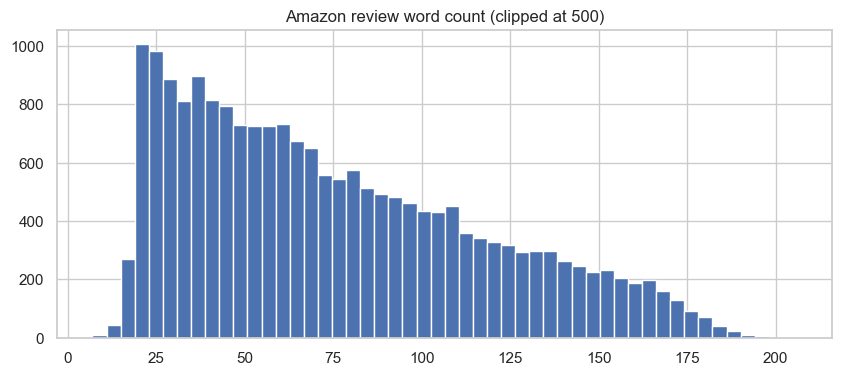

In [13]:
# Cell 5: Text length distributions (char & word counts)
def add_length_cols(df, col):
    df['char_len'] = df[col].astype(str).map(len)
    df['word_count'] = df[col].astype(str).map(lambda s: len(s.split()))
    return df

# adapt column names if different
amz_text_col = 'content' if 'content' in amz.columns else ('text' if 'text' in amz.columns else amz.columns[0])
goe_text_col = 'text' if 'text' in goe.columns else ('sentence' if 'sentence' in goe.columns else goe.columns[0])

add_length_cols(amz, amz_text_col)
add_length_cols(goe, goe_text_col)

print("Amazon length stats (chars):")
print(amz['char_len'].describe())
print("\nAmazon word count describe:")
print(amz['word_count'].describe())

plt.hist(amz['word_count'].clip(upper=500), bins=50); plt.title("Amazon review word count (clipped at 500)"); plt.show()

In [15]:
# Cell 6: Label distributions
if 'label' in amz.columns:
    display(amz['label'].value_counts().sort_index())

# For GoEmotions
if 'labels' in goe.columns:
    print("GoEmotions 'labels' sample:", goe['labels'].head(5).tolist())
else:
    # If one-hot or multi-columns, inspect few rows
    display(goe.head(3))

label
0     9743
1    10257
Name: count, dtype: int64

GoEmotions 'labels' sample: ['[27]', '[27]', '[2]', '[14]', '[3]']


In [17]:
# Cell 7: Examples to inspect noise patterns
for i, row in amz.sample(6, random_state=42).iterrows():
    t = str(row[amz_text_col])
    print("-" * 80)
    print(f"Len: {len(t)} chars, Words: {len(t.split())}")
    print(t[:1000])  # show first 1000 chars
    print()

--------------------------------------------------------------------------------
Len: 123 chars, Words: 22
It is very good but it is becoming little expoensive at amazon as compared to other brands available at stores like costco.

--------------------------------------------------------------------------------
Len: 383 chars, Words: 76
I think a couple of people are missing the point... The reason this is out is (I heard) they didn't have the cash to finish AV Vol 2, so this would generate some cash AND be of interest to their core fans. Plus, the demos ~are~ a good insight to their creative process.... I ~love~ to see the rough drafts... If you're just waiting for Vol 2, why did you buy this in the first place?

--------------------------------------------------------------------------------
Len: 170 chars, Words: 32
This book was so fascinating that I could not take a break from reading it. I look forward to reading Dr. Han's books The Secret Life of Quanta and The Probably Universe

In [18]:
# Cell 8: Basic cleaning demo and save sample
amz['text_clean'] = amz[amz_text_col].apply(basic_clean)
sample_save_path = DATA_PROCESSED / "amazon_sample_20k_clean.csv"
amz[['text_clean', 'label']].to_csv(sample_save_path, index=False)
print("Saved cleaned sample to:", sample_save_path)

Saved cleaned sample to: /Users/aayush/Documents/AI-Projects/GenAI-Summarization/genai-feedback-summarizer/data_processed/amazon_sample_20k_clean.csv


In [19]:
# Cell 9: Tokenizer length check (fast)
from transformers import AutoTokenizer
tk_name = "facebook/bart-base"  # faster than large
tokenizer = AutoTokenizer.from_pretrained(tk_name)

# sample a few to estimate token lengths
sample_texts = amz['text_clean'].sample(200, random_state=42).tolist()
token_lens = [len(tokenizer.encode(t, truncation=False)) for t in sample_texts]
import statistics
print("Tokenizer:", tk_name)
print("Median token length:", statistics.median(token_lens))
print("95th percentile token length:", np.percentile(token_lens, 95))
print("Max token length:", max(token_lens))

Tokenizer: facebook/bart-base
Median token length: 77.5
95th percentile token length: 196.04999999999998
Max token length: 223


Saved plot to: /Users/aayush/Documents/AI-Projects/GenAI-Summarization/genai-feedback-summarizer/docs/eda_length_hist.png
Saved EDA summary to docs/day2_eda_summary.json


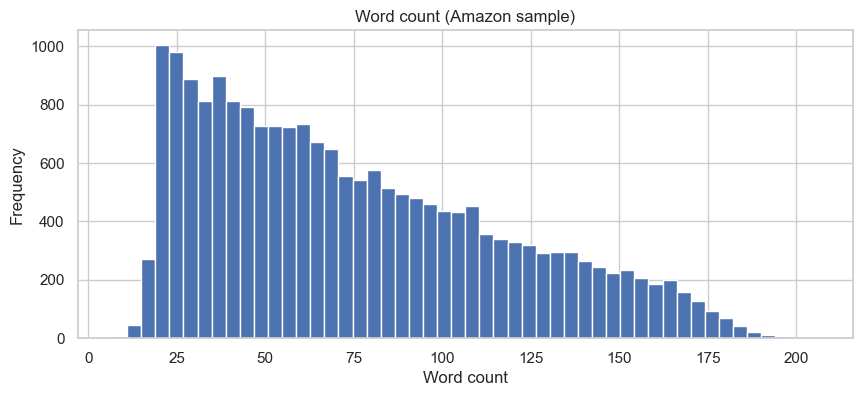

In [22]:
# Cell 10: Save plots and EDA notes
DOCS = ROOT / "docs"
DOCS.mkdir(parents=True, exist_ok=True)

plot_path = DOCS / "eda_length_hist.png"


plt.figure(figsize=(10,4))
plt.hist(amz['word_count'].clip(upper=500), bins=50)
plt.title("Word count (Amazon sample)")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.savefig(plot_path, bbox_inches='tight')
print("Saved plot to:", plot_path)

# Write a short note
notes = {
    "amz_sample_shape": amz.shape,
    "median_word_count": int(amz['word_count'].median()),
    "95pct_word_count": int(np.percentile(amz['word_count'], 95)),
    "tokenizer_test": {"model": tk_name}
}
json_path = DOCS / "day2_eda_summary.json"
with open(json_path, "w") as fh:
    json.dump(notes, fh, indent=2)
print("Saved EDA summary to docs/day2_eda_summary.json")